In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from rss import evaluate, features, preprocess, train, utils

print('✓ Core libraries imported')

✓ Core libraries imported


In [2]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/RF/sc'
FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/RF/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

for path in [FEATURE_DIR_SC, FEATURE_DIR_ST, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', FEATURE_DIR_SC, FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-cassette
ST: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-telemetry
Feature checkpoints: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
Model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF


In [ ]:
def discover_pairs(root_dir):
    """Return sorted (psg, hypnogram) pairs from a Sleep-EDF cohort directory."""
    psgs = sorted(Path(root_dir).glob('*-PSG.edf'))
    pairs = []
    for psg in psgs:
        subject_id = psg.name[:6]
        hyp_files = list(Path(root_dir).glob(f'{subject_id}*-Hypnogram.edf'))
        if hyp_files:
            pairs.append((psg, hyp_files[0]))
    return pairs


sc_pairs = discover_pairs(SC_DIR)
st_pairs = discover_pairs(ST_DIR)
print(f'SC pairs found: {len(sc_pairs)}')
print(f'ST pairs found: {len(st_pairs)}')

example_psg, example_hyp = sc_pairs[0]
raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
annotations = mne.read_annotations(example_hyp)
raw.set_annotations(annotations)

print(f'Example recording: {example_psg.name}')
print(f'Channels in file: {raw.ch_names}')
print(f'Sampling frequency: {raw.info["sfreq"]} Hz')
print(f'Duration: {raw.times[-1] / 3600:.2f} h')
print(f'Annotations: {len(annotations)} segments')

SC pairs found: 153
ST pairs found: 44


C:\Users\E1024679\AppData\Local\Temp\ipykernel_16140\2370535208.py:19: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_16140\2370535208.py:19: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_16140\2370535208.py:19: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>
Example recording: SC4001E0-PSG.edf
Channels in file: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 h
Annotations: 154 segments


C:\Users\E1024679\AppData\Local\Temp\ipykernel_16140\2370535208.py:22: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


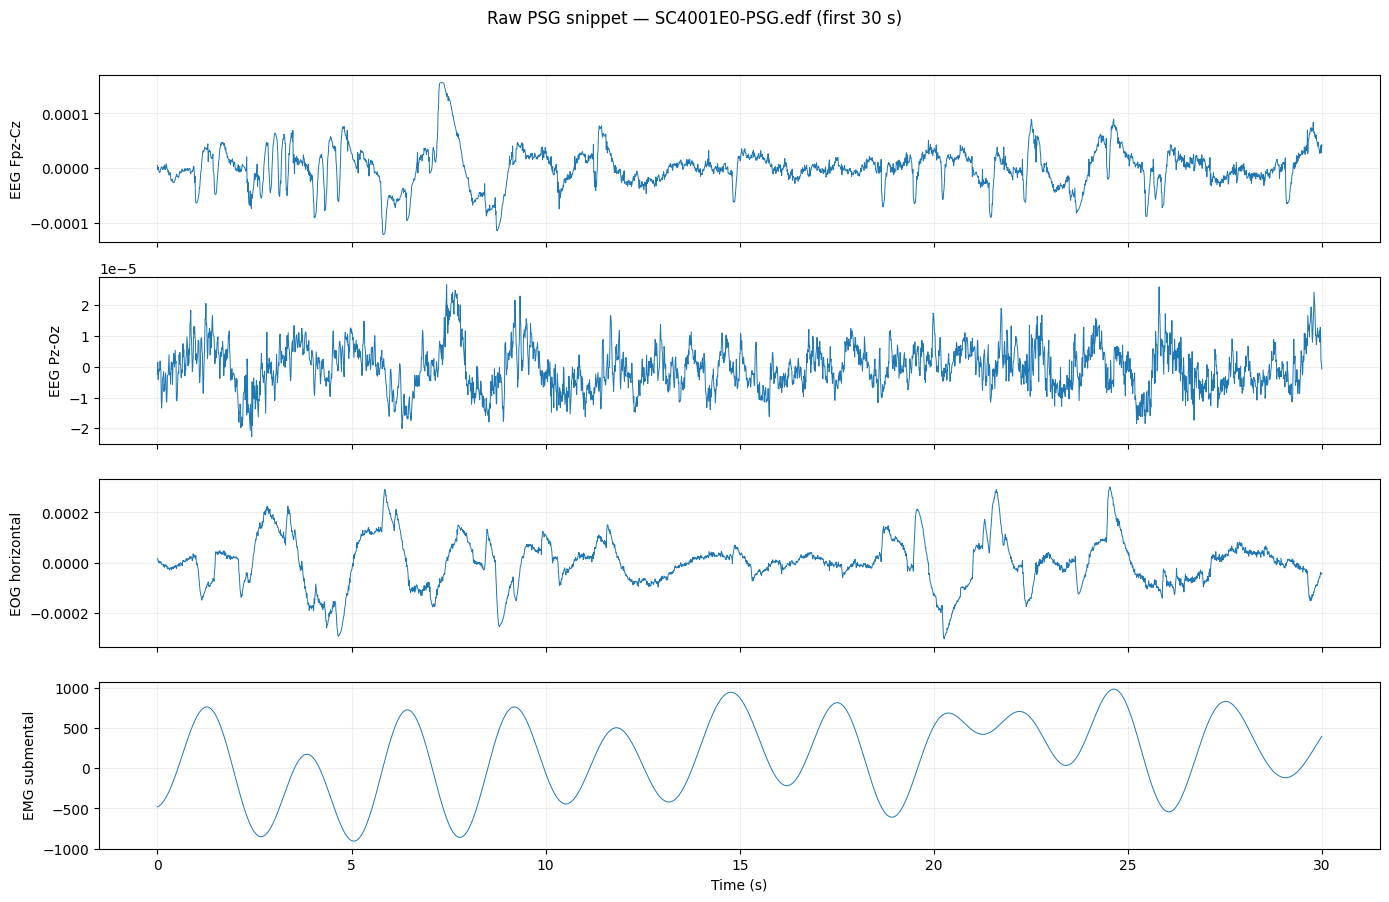

In [16]:
# Plot a short raw-signal snippet from the first few available channels
start_sec = 0
end_sec = 30
start_sample = int(start_sec * raw.info['sfreq'])
end_sample = int(end_sec * raw.info['sfreq'])
times = np.arange(start_sample, end_sample) / raw.info['sfreq']
data, _ = raw[: len(preprocess.COMMON_CHANNELS), start_sample:end_sample]

fig, axes = plt.subplots(len(preprocess.COMMON_CHANNELS), 1, figsize=(14, 2.2 * len(preprocess.COMMON_CHANNELS)), sharex=True)
if len(preprocess.COMMON_CHANNELS) == 1:
    axes = [axes]

for ax, channel, signal in zip(axes, preprocess.COMMON_CHANNELS, data):
    ax.plot(times, signal, lw=0.7)
    ax.set_ylabel(channel)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw PSG snippet — {example_psg.name} (first 30 s)', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
for ch in raw.info["chs"]:
    print(ch["ch_name"], ch["kind"], ch["unit"], ch["unit_mul"])

EEG Fpz-Cz 2 (FIFFV_EEG_CH) 107 (FIFF_UNIT_V) 0 (FIFF_UNITM_NONE)
EEG Pz-Oz 2 (FIFFV_EEG_CH) 107 (FIFF_UNIT_V) 0 (FIFF_UNITM_NONE)
EOG horizontal 2 (FIFFV_EEG_CH) 107 (FIFF_UNIT_V) 0 (FIFF_UNITM_NONE)
Resp oro-nasal 2 (FIFFV_EEG_CH) 107 (FIFF_UNIT_V) 0 (FIFF_UNITM_NONE)
EMG submental 2 (FIFFV_EEG_CH) 107 (FIFF_UNIT_V) 0 (FIFF_UNITM_NONE)
Temp rectal 2 (FIFFV_EEG_CH) 107 (FIFF_UNIT_V) 0 (FIFF_UNITM_NONE)
Event marker 2 (FIFFV_EEG_CH) 107 (FIFF_UNIT_V) 0 (FIFF_UNITM_NONE)


In [17]:
X_epochs, y_labels, sfreq = preprocess.load_subject_epochs(sc_pairs[0][0], sc_pairs[0][1], preprocess.COMMON_CHANNELS, verbose=True)
X_features, freqs = features.extract_psd_features(X_epochs, sfreq, verbose=True)
print(f'Feature matrix shape: {X_features.shape}')

[preprocess] loading PSG: SC4001E0-PSG.edf, hypnogram: SC4001EC-Hypnogram.edf


c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:26: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:26: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:26: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] extracted epochs: 2650 epochs, shape per epoch: (4, 3000) 
[features] computing PSD for 2650 epochs (sfreq=100.0)
[features] PSD computed — elapsed: 4.2s, psd shape: (2650, 4, 1186)
Feature matrix shape: (2650, 4744)


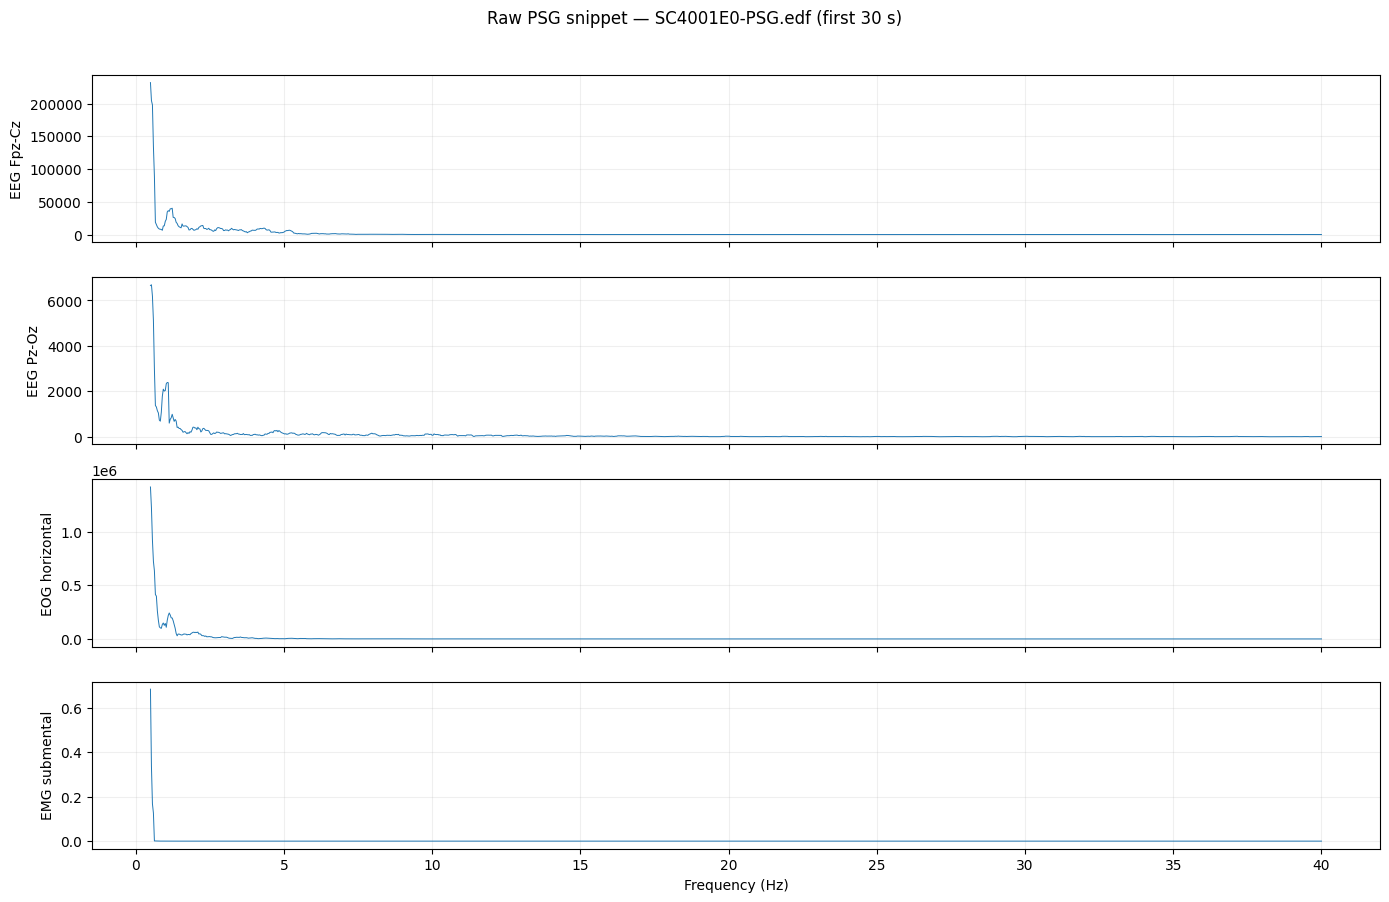

In [ ]:
fig, axes = plt.subplots(len(preprocess.COMMON_CHANNELS), 1, figsize=(14, 2.2 * len(preprocess.COMMON_CHANNELS)), sharex=True)
if len(preprocess.COMMON_CHANNELS) == 1:
    axes = [axes]

for i_channel, (ax, channel, signal) in enumerate(zip(axes, preprocess.COMMON_CHANNELS, data)):
    psd = X_features[0, i_channel * len(freqs):(i_channel + 1) * len(freqs)]# Convert from V^2 to uV^2
    ax.plot(freqs, psd, lw=0.7)
    ax.set_ylabel(channel)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle(f'Raw PSG snippet — {example_psg.name} (first 30 s)', y=1.02)
plt.tight_layout()